# 2. Forecasting Models and Baselines

Trains the two XGBoost regressors (PV generation, EV demand), and checks them against a naive persistence baseline and a ridge regression baseline on the same held-out split. This mirrors the comparison reported in the paper (Section VI).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import matplotlib.pyplot as plt
import pandas as pd

from evloadshaping.data import load_raw_data
from evloadshaping.features import build_features, split_data
from evloadshaping.models import (
    compute_baselines,
    evaluate_model,
    run_feature_ablation,
    train_model,
)
from evloadshaping.plotting import plot_forecasts

DATA_PATH = Path('../data/20260514_uma_adabyron_data.csv')

## Load, engineer features, and split

Same chronological 80/20 split used throughout the project — no shuffling, so the test set is strictly the most recent ~20% of intervals.

In [2]:
raw_frame, charger_ids = load_raw_data(DATA_PATH)
feature_frame = build_features(raw_frame, charger_ids)
x_train, x_test, y_pv_train, y_pv_test, y_ev_train, y_ev_test = split_data(feature_frame)
print(f'Train: {len(x_train):,} rows | Test: {len(x_test):,} rows')

Train: 46,144 rows | Test: 11,537 rows


## Train the XGBoost forecasters

In [3]:
model_pv = train_model(x_train, y_pv_train)
model_ev = train_model(x_train, y_ev_train)

pv_predictions = model_pv.predict(x_test)
ev_predictions = model_ev.predict(x_test)

pv_metrics = evaluate_model(y_pv_test, pv_predictions)
ev_metrics = evaluate_model(y_ev_test, ev_predictions)

pd.DataFrame({'PV forecast': pv_metrics, 'EV demand forecast': ev_metrics}).round(2)

,PV forecast,EV demand forecast
mae,453.87,64.86
rmse,963.92,296.19


## Baseline comparison

Persistence predicts the next interval as equal to the current one; ridge regression uses the same engineered features as XGBoost. This is where the paper's honest negative result shows up: persistence is competitive with (or beats) XGBoost for EV demand.

In [4]:
baselines = compute_baselines(x_test, y_pv_test, y_ev_test, x_train, y_pv_train, y_ev_train)

comparison = pd.DataFrame([
    {'model': 'persistence', 'target': 'pv', **baselines['persistence']['pv']},
    {'model': 'ridge_regression', 'target': 'pv', **baselines['ridge_regression']['pv']},
    {'model': 'xgboost', 'target': 'pv', **pv_metrics},
    {'model': 'persistence', 'target': 'ev', **baselines['persistence']['ev']},
    {'model': 'ridge_regression', 'target': 'ev', **baselines['ridge_regression']['ev']},
    {'model': 'xgboost', 'target': 'ev', **ev_metrics},
])
comparison.round(2)

,model,target,mae,rmse
0,persistence,pv,465.35,1024.03
1,ridge_regression,pv,503.99,977.85
2,xgboost,pv,453.87,963.92
3,persistence,ev,52.29,273.24
4,ridge_regression,ev,64.41,265.35
5,xgboost,ev,64.86,296.19


## Feature ablation

How much do the lag/rolling-window features actually contribute over a current-timestep-only model?

In [5]:
ablation = run_feature_ablation(x_train, x_test, y_pv_train, y_pv_test, y_ev_train, y_ev_test)

ablation_table = pd.DataFrame([
    {'feature_set': 'base_only', 'target': 'pv', **ablation['base_features_only']['pv']},
    {'feature_set': 'full', 'target': 'pv', **pv_metrics},
    {'feature_set': 'base_only', 'target': 'ev', **ablation['base_features_only']['ev']},
    {'feature_set': 'full', 'target': 'ev', **ev_metrics},
])
ablation_table.round(2)

,feature_set,target,mae,rmse
0,base_only,pv,544.05,1142.20
1,full,pv,453.87,963.92
2,base_only,ev,77.88,333.91
3,full,ev,64.86,296.19


## Feature importance

Top features by XGBoost gain for each target.

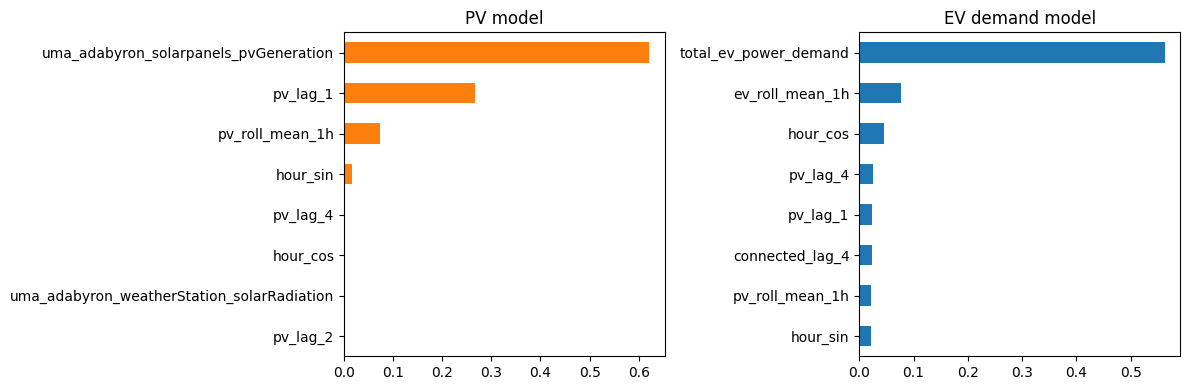

In [6]:
def top_importances(model, feature_names, n=8):
    return (
        pd.Series(model.feature_importances_, index=feature_names)
        .sort_values(ascending=False)
        .head(n)
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
top_importances(model_pv, x_train.columns).plot.barh(ax=axes[0], color='tab:orange')
axes[0].invert_yaxis()
axes[0].set_title('PV model')

top_importances(model_ev, x_train.columns).plot.barh(ax=axes[1], color='tab:blue')
axes[1].invert_yaxis()
axes[1].set_title('EV demand model')
fig.tight_layout()
plt.show()

## Forecast trace over the test horizon

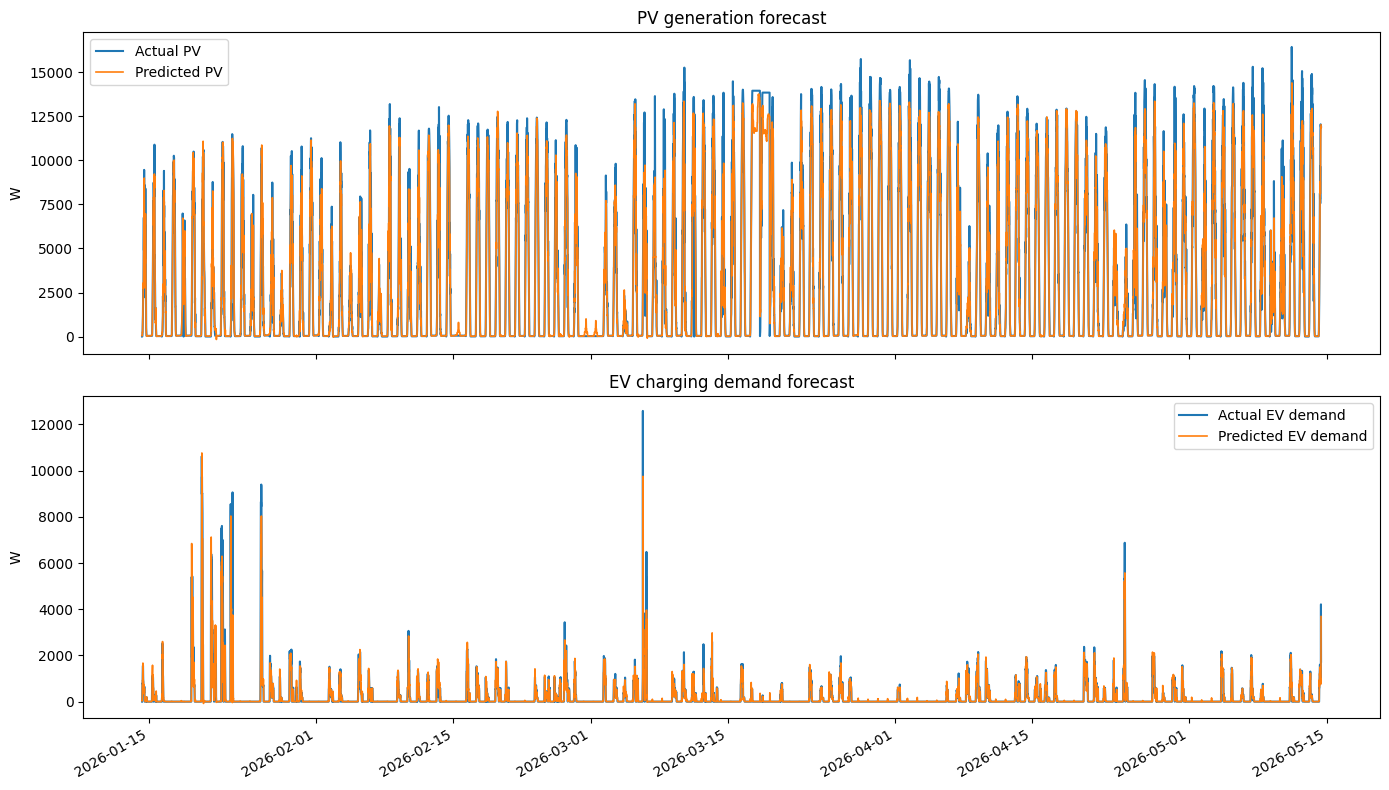

In [7]:
fig = plot_forecasts(
    test_index=x_test.index,
    actual_pv=y_pv_test,
    predicted_pv=pv_predictions,
    actual_ev=y_ev_test,
    predicted_ev=ev_predictions,
)
plt.show()